In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import dash
from dash import dash_table, html
import plotly
import sqlite3

db_path = "polymarket.db"
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Get all table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [t[0] for t in cursor.fetchall()]

# Get the column names for each table for reference
for table in tables:
    print(f"\nTable: {table}")
    
    cursor.execute(f"PRAGMA table_info({table});")
    columns = cursor.fetchall()
    
    column_names = [col[1] for col in columns]  # col[1] is the column name
    print("Columns:", column_names)


Table: events
Columns: ['id', 'slug', 'title', 'description', 'active', 'closed', 'created_at', 'updated_at', 'neg_risk', 'volume', 'liquidity', 'category', 'tags', 'volume_24hr', 'series_slug', 'competitive', 'comment_count', 'open_interest', 'start_date']

Table: tokens
Columns: ['token_id', 'condition_id', 'outcome', 'created_at']

Table: price_history
Columns: ['id', 'token_id', 'timestamp', 'price', 'fidelity_minutes', 'created_at']

Table: sqlite_sequence
Columns: ['name', 'seq']

Table: sync_metadata
Columns: ['token_id', 'last_timestamp', 'interval', 'fidelity_minutes', 'record_count', 'synced_at']

Table: order_book_levels
Columns: ['id', 'snapshot_id', 'side', 'price', 'size', 'created_at']

Table: sqlite_stat1
Columns: ['tbl', 'idx', 'stat']

Table: schema_migrations
Columns: ['id', 'migration_name', 'applied_at', 'description']

Table: order_book_snapshots
Columns: ['id', 'token_id', 'timestamp', 'created_at']

Table: markets
Columns: ['condition_id', 'event_id', 'question

# SQL Data Extraction

## Part A

In [2]:
# provide counts for each table
counts = []

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table};")
    count = cursor.fetchone()[0]
    counts.append((table, count))

counts_df = pd.DataFrame(counts, columns=["Table Name", "Row Count"])
counts_df

,Table Name,Row Count
0,events,183883
1,tokens,257315
2,price_history,2713283
3,sqlite_sequence,4
4,sync_metadata,257315
5,order_book_levels,912653
6,sqlite_stat1,7
7,schema_migrations,2
8,order_book_snapshots,23094
9,markets,425933


## Part B

In [3]:
# get the top 10 markets by trading volume

cursor.execute("""
    SELECT question, volume, closed 
    FROM markets 
    ORDER BY volume DESC 
    LIMIT 10;
""")

top_markets = cursor.fetchall()

top_markets_df = pd.DataFrame(
    top_markets,
    columns=["Question", "Volume", "Closed"]
)

top_markets_df

,Question,Volume,Closed
0,Will Donald Trump win the 2024 US Presidential...,1.531479e+09,1
1,Will Kamala Harris win the 2024 US Presidentia...,1.037039e+09,1
2,Will Donald Trump be inaugurated?,4.004095e+08,1
3,Will the Sacramento Kings win the 2025 NBA Fin...,3.780115e+08,1
4,Will Nicolae Ciucă win the 2024 Romanian Presi...,3.265077e+08,1
5,Will Zelenskyy wear a suit before July?,2.422312e+08,1
6,Will any other Republican Politician win the 2...,2.416551e+08,1
7,Fed decreases interest rates by 50+ bps after ...,2.350652e+08,1
8,Fed increases interest rates by 25+ bps after ...,2.164557e+08,1
9,Kamala Harris wins the popular vote?,1.637798e+08,1


## Part C

In [4]:
# Filtering for resolved markets, getting market question, max price, recent price, and number of price history records

cursor.execute("""
    SELECT 
        m.question,
        MAX(ph.price) AS peak_price,
        (
            SELECT ph2.price
            FROM price_history ph2
            WHERE ph2.token_id = t.token_id
            ORDER BY ph2.timestamp DESC
            LIMIT 1
        ) AS final_price,
        COUNT(ph.id) AS price_record_count
    FROM markets m
    JOIN tokens t
        ON t.condition_id = m.condition_id
    JOIN price_history ph
        ON ph.token_id = t.token_id
    WHERE m.closed = 1
      AND t.outcome = 'Yes'
    GROUP BY m.question, t.token_id
    HAVING COUNT(ph.id) >= 5
    LIMIT 5
""")

resolved_sample = cursor.fetchall()

resolved_sample_df = pd.DataFrame(
    resolved_sample,
    columns=[
        "Question",
        "Peak Price",
        "Final Price",
        "Price Record Count"
    ]
)

resolved_sample_df

,Question,Peak Price,Final Price,Price Record Count
0,Claudine Gay still Harvard President by end o...,0.9705,0.9565,26
1,Israel and Hamas ceasefire in 2023?,0.9795,0.9795,48
2,Will Iranian officials visit the White House ...,0.0700,0.0055,19
3,Will Nina Brunner & Tanja Huberli (SUI) win G...,0.4800,0.1500,6
4,Will Trump mention DeSantis more than Biden d...,0.5000,0.5000,7


## Part D

This sum represents the total probability across all possible outcomes for the number of Fed rate cuts in 2026. Each “Yes” token price reflects the probability of a specific number occurring. Since these outcomes are mutually exclusive and cover the entire sample space, the sum of all “Yes” token prices should be 1. In other words, the total probability of all possible scenarios for Fed rate cuts in 2026 should equal 1.

In [5]:
# Finding all markets for Fed rate cuts and displaying the question, their latest yes token price, and the sum of latest Yes token prices

cursor.execute("""
    SELECT 
        question,
        latest_yes_price,
        SUM(latest_yes_price) OVER () AS total_yes_price
    FROM (
        SELECT 
            m.question,
            ph.price AS latest_yes_price,
            ROW_NUMBER() OVER (
                PARTITION BY t.token_id 
                ORDER BY ph.timestamp DESC
            ) AS rn
        FROM markets m
        JOIN events e ON e.id = m.event_id
        JOIN tokens t 
            ON t.condition_id = m.condition_id
            AND t.outcome = 'Yes'
        JOIN price_history ph
            ON ph.token_id = t.token_id
        WHERE e.id = 51456
    ) sub
    WHERE rn = 1
""")

fed_probs = cursor.fetchall()

fed_probs_df = pd.DataFrame(
    fed_probs,
    columns=[
        "Question",
        "Latest Yes Price",
        "Total Yes Price (All Markets)"
    ]
)

fed_probs_df

,Question,Latest Yes Price,Total Yes Price (All Markets)
0,Will 10 Fed rate cuts happen in 2026?,0.0055,1.041
1,Will 1 Fed rate cut happen in 2026?,0.1350,1.041
2,Will no Fed rate cuts happen in 2026?,0.0650,1.041
3,Will 9 Fed rate cuts happen in 2026?,0.0065,1.041
4,Will 5 Fed rate cuts happen in 2026?,0.0600,1.041
5,Will 11 Fed rate cuts happen in 2026?,0.0050,1.041
6,Will 2 Fed rate cuts happen in 2026?,0.2350,1.041
7,Will 4 Fed rate cuts happen in 2026?,0.1500,1.041
8,Will 6 Fed rate cuts happen in 2026?,0.0415,1.041
9,Will 8 Fed rate cuts happen in 2026?,0.0110,1.041


## Part E

In [6]:
# Filtering for large events, we got the top 10 largest events by trading volume and the counts on their distinct markets and tokens

cursor.execute("""
    SELECT
        e.title,
        COUNT(DISTINCT m.event_id) AS num_markets,
        COUNT(DISTINCT t.token_id) AS num_tokens,
        SUM(m.volume) AS total_volume
    FROM events e
    JOIN markets m ON m.event_id = e.id
    JOIN tokens t ON t.condition_id = m.condition_id
    WHERE e.volume > 100000000
    GROUP BY e.id, e.title
    ORDER BY total_volume DESC
    LIMIT 10
""")

large_events = cursor.fetchall()

large_events_df = pd.DataFrame(
    large_events,
    columns=[
        "Event Title",
        "Number of Markets",
        "Number of Tokens",
        "Total Market Volume"
    ]
)

large_events_df

,Event Title,Number of Markets,Number of Tokens,Total Market Volume
0,Presidential Election Winner 2024,1,34,7.372670e+09
1,Big Game Champion 2026,1,62,1.311627e+09
2,Democratic Presidential Nominee 2028,1,86,1.274756e+09
3,Popular Vote Winner 2024,1,34,1.256327e+09
4,Who will Trump nominate as Fed Chair?,1,54,8.927601e+08
5,Democratic Nominee 2024,1,18,6.557323e+08
6,Presidential Election Winner 2028,1,60,5.507206e+08
7,Republican Presidential Nominee 2028,1,64,5.392447e+08
8,Fed decision in October?,1,8,5.049711e+08
9,2026 NBA Champion,1,60,4.911275e+08


# Market Efficiency Analysis

## Methodology

To evaluate prediction market efficiency, this report employs a composite methodology combining the Pipping Framework (Blown Lead Paradox) and the SciCast Framework. A market is considered efficient if prices are unbiased, well-calibrated forecasts that incorporate available information without systematic distortion. This dual approach audits both internal consistency (rationality of price paths) and information assimilation (accuracy over time). The analysis focuses exclusively on resolved binary markets with complete price histories.

The Pipping Framework tests for structural bias by isolating contracts that resolved at 0 (failed outcomes). For each losing contract, the maximum historical price is recorded and compared against theoretical martingale bounds. If the frequency of these "blown leads" (e.g., rising from 0.50 to 0.80 before crashing) exceeds mathematical limits, it quantifies a structural "hype premium" where the market prices possibility as probability.

The Calibration Framework evaluates accuracy through static and temporal lenses. First, a standard Reliability Diagram bins price observations (e.g., 0.05–0.15) to compare implied probabilities against empirical win rates, explicitly testing for over/under-confidence.  Subsequently, the SciCast Framework measures temporal learning. A binary ground truth vector (1 if final price > 0.50, else 0) allows every historical price to be scored using the Brier Score. We are implying that the winner of each market is just the one with the higher probability, as prices right before resolution would tend towards the correct outcome. Plotting average error against time-to-resolution reveals the market's learning curve, as an efficient market should show a steep downward slope as resolution approaches.

To ensure robustness and avoid selection bias, the analysis utilizes the full Polymarket dataset rather than a curated subset. Timestamps are standardized to UTC, and outcomes are definitively resolved using a final settlement threshold (>0.50) to establish a consistent binary ground truth across all contracts.



### Step 1: Data Processing and Feature Engineering

In [7]:
# Load only 'Yes' tokens to prevent double-counting 
df_tokens = pd.read_sql("SELECT * FROM tokens WHERE outcome = 'Yes'", conn)

df_history = pd.read_sql("SELECT * FROM price_history", conn)

# Load only closed markets to ensure definitive outcomes
df_markets = pd.read_sql("SELECT * FROM markets WHERE closed = 1", conn)

# Create a master dataframe combining Tokens, History, and Market context
df_merged = df_tokens.merge(df_history, on='token_id', how='inner')
df_master = df_merged.merge(df_markets, on='condition_id', how='inner')

# Sort by time to ensure accuracy when calculating final prices
df_master = df_master.sort_values(['token_id', 'timestamp'])

# Logic: If the final price > 0.50, we treat it as a 'Win' (1)
final_prices = df_master.groupby('token_id')['price'].last()
df_master['actual_outcome'] = np.where(
    df_master['token_id'].map(final_prices) > 0.50, 1, 0
)

# Isolate contracts that ultimately lost (outcome == 0)
df_losers = df_master[df_master['actual_outcome'] == 0].copy()

# Find the maximum price these losers ever reached (The "Hype Peak")
loser_max_prices = df_losers.groupby('token_id')['price'].max()

### Step 2: Create the Calibration Chart

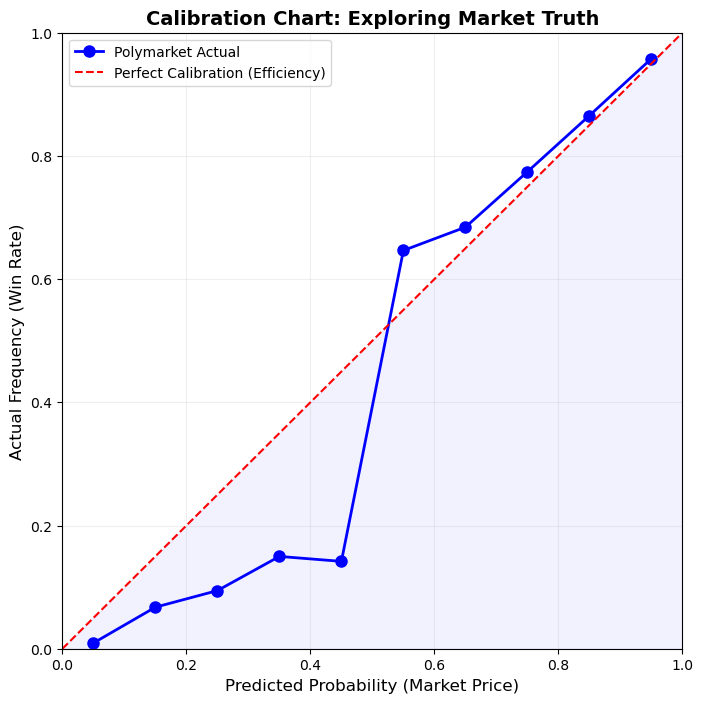

In [8]:
# Ensure price is between 0 and 1
df_cal = df_master[['price', 'actual_outcome']].copy()
df_cal = df_cal[(df_cal['price'] >= 0) & (df_cal['price'] <= 1)]

# Create bins (0.0 to 1.0 in 10% steps). We label them by the midpoint (e.g., 0.05, 0.15...)
df_cal['bin'] = pd.cut(df_cal['price'], 
                       bins=np.arange(0, 1.1, 0.1), 
                       labels=np.arange(0.05, 1.05, 0.1))

# Calculate actual frequency per bin, which tells us: "When the price was X, how often did it actually resolve to 1?"
calibration = df_cal.groupby('bin', observed=False)['actual_outcome'].mean().reset_index()
calibration['bin'] = calibration['bin'].astype(float)

# Plot the Market's performance
plt.figure(figsize=(8, 8))
plt.plot(calibration['bin'], calibration['actual_outcome'], 
         marker='o', markersize=8, linewidth=2, color='blue', label='Polymarket Actual')

# Plot the "Perfect Calibration" Line (The Diagonal)
plt.plot([0, 1], [0, 1], linestyle='--', color='red', label='Perfect Calibration (Efficiency)')

# Formatting
plt.title('Calibration Chart: Exploring Market Truth', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Probability (Market Price)', fontsize=12)
plt.ylabel('Actual Frequency (Win Rate)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.2)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.fill_between([0, 1], [0, 1], [0, 0], color='blue', alpha=0.05, label='Over-confident Zone')
plt.savefig("calibrationchart.png")
plt.show()


### Step 3: Testing If Price Paths Follow A Martingale Process

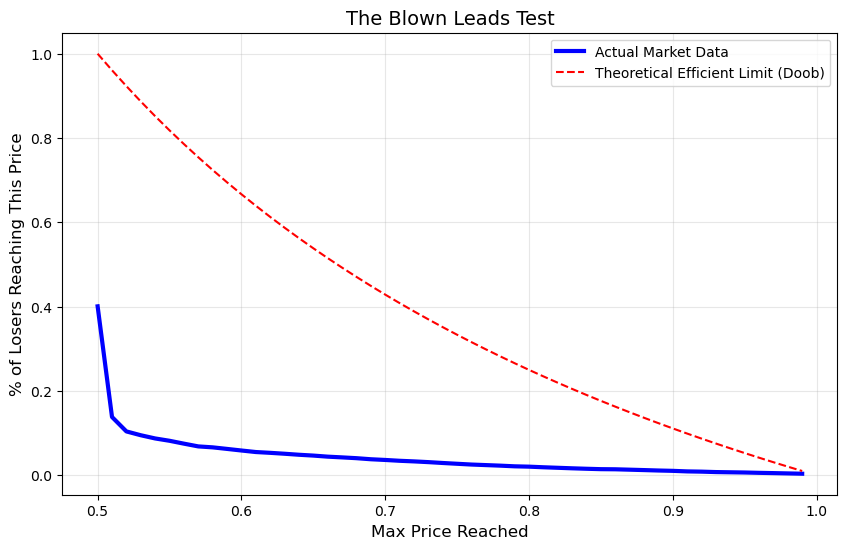

In [9]:
thresholds = np.linspace(0.50, 0.99, 50)

# Calculates what % of losers reached this price
actual_ratios = []
for t in thresholds:
    count = (loser_max_prices >= t).sum()
    ratio = count / len(loser_max_prices)
    actual_ratios.append(ratio)

# Calculate Theoretical Efficient Limit
# Formula: P(Max >= b | Lose) = (p * (1-b)) / (b * (1-p))
# Assuming start price p = 0.50
theoretical_ratios = [(0.50 * (1 - b)) / (b * (1 - 0.50)) for b in thresholds]

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, actual_ratios, label='Actual Market Data', color='blue', linewidth=3)
plt.plot(thresholds, theoretical_ratios, label='Theoretical Efficient Limit (Doob)', color='red', linestyle='--')
plt.title('The Blown Leads Test', fontsize=14)
plt.xlabel('Max Price Reached', fontsize=12)
plt.ylabel('% of Losers Reaching This Price', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("blownleadstest.png")
plt.show()

### Step 4: Checking Information Assimilation Over Time


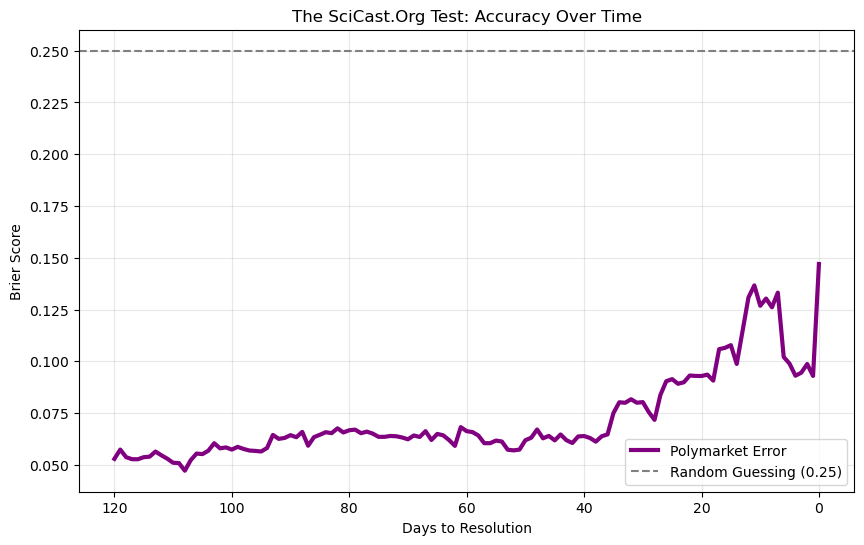

In [10]:
df_fix = df_master.copy()

# Fix time_scale and convert times to UTC
for col in ['timestamp', 'end_date']:
    df_fix[col] = pd.to_datetime(df_master[col], unit='s', errors='coerce', utc=True)

    if df_fix[col].dropna().empty or df_fix[col].dt.year.mean() < 2000:
        df_fix[col] = pd.to_datetime(df_master[col], errors='coerce', utc=True)

# Clean and align our data
df_fix = df_fix.dropna(subset=['timestamp', 'end_date', 'price'])
df_fix = df_fix.sort_values(["token_id", "timestamp"])

# Ee-calculate the win/loss since the variable was cleared
final_prices = df_fix.groupby('token_id')['price'].last()
df_fix['actual_outcome'] = np.where(df_fix['token_id'].map(final_prices) > 0.50, 1, 0)
df_fix['days_remaining'] = (df_fix['end_date'] - df_fix['timestamp']).dt.days

# 5. Plot data from 0 - 120 days
df_michigan = df_fix[(df_fix['days_remaining'] >= 0) & (df_fix['days_remaining'] <= 120)].copy()

df_michigan['sq_error'] = (df_michigan['price'] - df_michigan['actual_outcome']) ** 2
curve = df_michigan.groupby('days_remaining')['sq_error'].mean().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(curve['days_remaining'], curve['sq_error'], color='purple', linewidth=3, label='Polymarket Error')
plt.axhline(y=0.25, color='gray', linestyle='--', label='Random Guessing (0.25)')
    
plt.gca().invert_xaxis() 
plt.title('The SciCast.Org Test: Accuracy Over Time')
plt.xlabel('Days to Resolution')
plt.ylabel('Brier Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("scicasttest.png")
plt.show()

### Step 5: Analyzing Wisdom of the Crowds In Prediction Markets

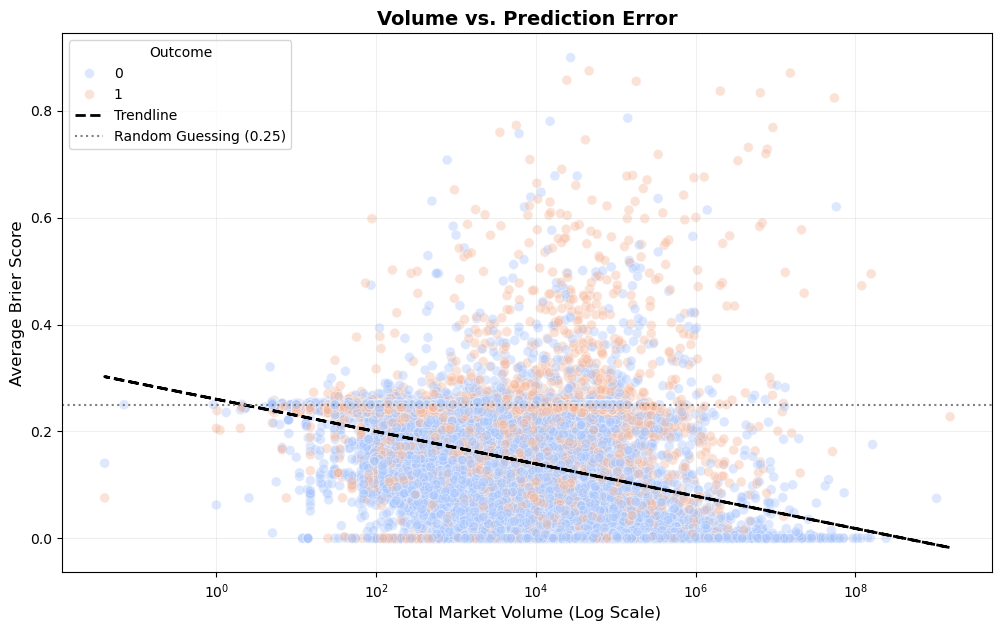

Correlation between Log(Volume) and Error: -0.3511


In [11]:
# Calculate squared error for every single data point
df_master['sq_error'] = (df_master['price'] - df_master['actual_outcome']) ** 2

# Group by Token to get a "Report Card" for each market
market_stats = df_master.groupby('token_id').agg({
    'sq_error': 'mean',       # Average error over the market's life (Accuracy)
    'volume': 'max',          # The total volume reached (Size)
    'actual_outcome': 'max'   # Just to color code winners/losers if needed
}).reset_index()

# Filter out zero-volume markets to avoid log-scale errors
market_stats = market_stats[market_stats['volume'] > 0]

# Create the Scatter Plot
plt.figure(figsize=(12, 7))
sb.scatterplot(
    data=market_stats, 
    x='volume', 
    y='sq_error', 
    hue='actual_outcome',   
    palette='coolwarm',      
    alpha=0.4, 
    s=50               
)

# We fit a simple line to see the error volume relationship
z = np.polyfit(np.log(market_stats['volume']), market_stats['sq_error'], 1)
p = np.poly1d(z)
plt.plot(market_stats['volume'], p(np.log(market_stats['volume'])), "k--", linewidth=2, label='Trendline')

plt.xscale('log')  # Volume varies wildly, so log scale is required
plt.title('Volume vs. Prediction Error', fontsize=14, fontweight='bold')
plt.xlabel('Total Market Volume (Log Scale)', fontsize=12)
plt.ylabel('Average Brier Score', fontsize=12)
plt.axhline(y=0.25, color='gray', linestyle=':', label='Random Guessing (0.25)')
plt.legend(title='Outcome')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.savefig("volumevspredictionerror.png")
plt.show()

correlation = market_stats['volume'].apply(np.log).corr(market_stats['sq_error'])
print(f"Correlation between Log(Volume) and Error: {correlation:.4f}")

### Step 6: Comparing Across Different Types of Markets 

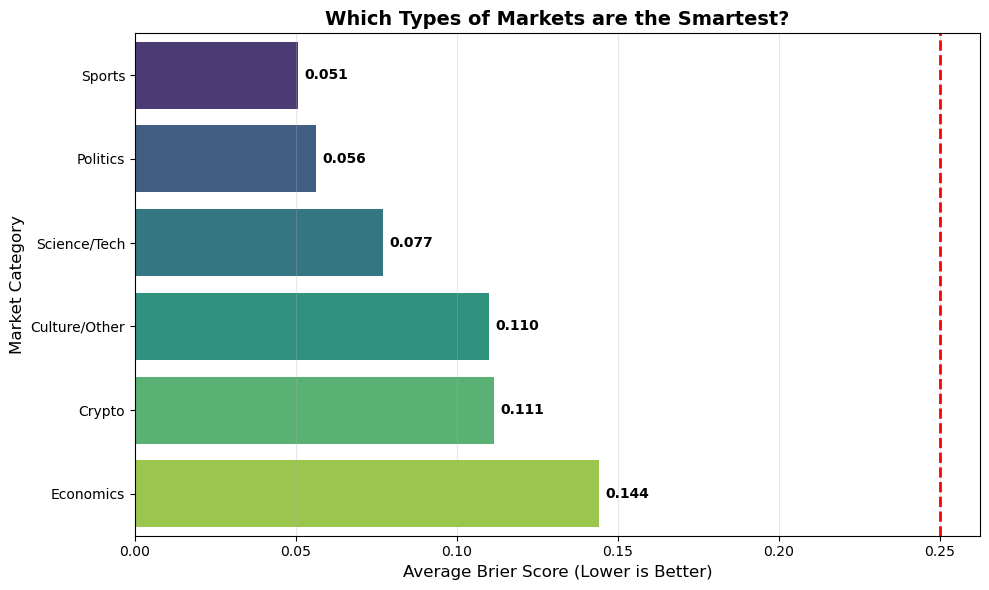

In [12]:
def assign_category(text):
    text = str(text).lower()
    if any(x in text for x in ['trump', 'biden', 'election', 'senate', 'gop', 'democrat', 'president', 'pol']):
        return 'Politics'
    elif any(x in text for x in ['bitcoin', 'eth', 'solana', 'crypto', 'nft', 'token', 'chain']):
        return 'Crypto'
    elif any(x in text for x in ['rate', 'fed', 'inflation', 'gdp', 'recession', 'bank']):
        return 'Economics'
    elif any(x in text for x in ['nfl', 'nba', 'super bowl', 'messi', 'f1', 'sport']):
        return 'Sports'
    elif any(x in text for x in ['temp', 'covid', 'spacex', 'nasa', 'climate', 'science']):
        return 'Science/Tech'
    else:
        return 'Culture/Other'

df_master['category'] = df_master["question"].apply(assign_category)

# Calculate efficiency
cat_efficiency = df_master.groupby('category')['sq_error'].mean().reset_index()
cat_efficiency = cat_efficiency.sort_values('sq_error', ascending=True)

# PLot results
plt.figure(figsize=(10, 6))

ax = sb.barplot(
    data=cat_efficiency, 
    x='sq_error', 
    y='category', 
    hue='category', 
    palette='viridis', 
    legend=False
)

# Add the benchmark Line (0.25 is the Brier Score for a coin flip)
plt.axvline(x=0.25, color='red', linestyle='--', linewidth=2, label='Random Guessing (0.25)')

plt.title('Which Types of Markets are the Smartest?', fontsize=14, fontweight='bold')
plt.xlabel('Average Brier Score (Lower is Better)', fontsize=12)
plt.ylabel('Market Category', fontsize=12)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(cat_efficiency['sq_error']):
    ax.text(v + 0.002, i, f"{v:.3f}", va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("differentmarkets.png")
plt.show()

## Written Analysis

Markets are directionally well-calibrated overall, but exhibit systematic overconfidence in the tails. The reliability diagram shows that high-probability contracts are particularly accurate: outcomes trading above 0.80 resolve successfully at very high rates, indicating strong calibration for favorites. However, mid-to-low probability contracts systematically underperform their implied odds. For example, contracts trading around 0.35 resolve successfully only about 15% of the time. This pattern is consistent with a classic longshot bias, where traders overpay for unlikely outcomes. Thus, while markets are well-calibrated at the top end, they are over-confident when pricing underdogs.

Several structural patterns emerge. First, liquidity strongly improves accuracy: higher-volume markets exhibit lower Brier scores, suggesting that increased participation reduces mispricing. Second, calibration varies by sector, with high-visibility categories such as Sports and Politics substantially more accurate than lower-attention areas like Economics. Finally, error rates appear to increase slightly in the final days before resolution, indicating possible late-stage volatility or speculative noise. Overall, prediction markets are broadly well-calibrated, but display predictable inefficiencies tied to probability level, liquidity, and timing.


In [13]:
# Proper ISO8601 parsing (handles .999Z timestamps)
df_master['end_date'] = pd.to_datetime(
    df_master['end_date'],
    format='ISO8601',
    utc=True
)

# Use MAX for cumulative volume
leaderboard_df = df_master.groupby(
    ['token_id', 'question', 'end_date'],
    as_index=False
).agg({
    'price': 'max',
    'actual_outcome': 'max',
    'volume': 'max'
})

leaderboard_df.columns = [
    'Token ID',
    'Market Question',
    'End Date',
    'Peak Price',
    'Outcome',
    'Volume'
]

# --------------------------------------------------------- 
# 2. EFFICIENCY CALCULATION
# --------------------------------------------------------- 
leaderboard_df['Error Score'] = (
    leaderboard_df['Peak Price'] - leaderboard_df['Outcome']
) ** 2

leaderboard_df['Error Score'] = leaderboard_df['Error Score'].round(3)

# Store raw numeric values
leaderboard_df['Volume Raw'] = leaderboard_df['Volume']
leaderboard_df['Outcome Raw'] = leaderboard_df['Outcome']

# --------------------------------------------------------- 
# 3. FORMATTING FOR DISPLAY
# --------------------------------------------------------- 
leaderboard_df['Peak Price'] = (
    (leaderboard_df['Peak Price'] * 100)
    .round(1)
    .astype(str) + '%'
)

leaderboard_df['Outcome'] = leaderboard_df['Outcome'].map({
    1: '✓ WIN',
    0: '✗ LOSS'
})

leaderboard_df['End Date'] = leaderboard_df['End Date'].dt.strftime('%Y-%m-%d')

leaderboard_df['Volume'] = leaderboard_df['Volume'].apply(
    lambda x: f"{x:,.0f}"
)

# --------------------------------------------------------- 
# 4. DASH APP
# --------------------------------------------------------- 
app = dash.Dash(__name__)

app.layout = html.Div([

    # Header
    html.Div([
        html.H1("📊 Polymarket Efficiency Explorer",
                style={
                    'textAlign': 'center',
                    'fontFamily': 'system-ui, -apple-system, sans-serif',
                    'color': '#111827',
                    'fontWeight': '700'
                }),
        html.P("Analyze prediction market accuracy and trader behavior",
               style={
                   'textAlign': 'center',
                   'color': '#6b7280',
                   'fontSize': '1.05rem'
               })
    ], style={'paddingTop': '30px', 'paddingBottom': '20px'}),

    # Stats Cards
    html.Div([
        html.Div([

            html.Div([
                html.H3(f"{len(leaderboard_df):,}",
                        style={'margin': '0', 'color': '#2563eb', 'fontSize': '2rem'}),
                html.P("Total Markets",
                       style={'margin': '5px 0 0 0', 'color': '#6b7280'})
            ], style={
                'backgroundColor': '#f0f9ff',
                'padding': '20px',
                'borderRadius': '14px',
                'textAlign': 'center',
                'flex': '1',
                'margin': '0 10px'
            }),

            html.Div([
                html.H3(f"${leaderboard_df['Volume Raw'].sum():,.0f}",
                        style={'margin': '0', 'color': '#16a34a', 'fontSize': '2rem'}),
                html.P("Total Trading Volume",
                       style={'margin': '5px 0 0 0', 'color': '#6b7280'})
            ], style={
                'backgroundColor': '#f0fdf4',
                'padding': '20px',
                'borderRadius': '14px',
                'textAlign': 'center',
                'flex': '1',
                'margin': '0 10px'
            }),

            html.Div([
                html.H3(f"{leaderboard_df['Error Score'].mean():.3f}",
                        style={'margin': '0', 'color': '#dc2626', 'fontSize': '2rem'}),
                html.P("Avg Error Score",
                       style={'margin': '5px 0 0 0', 'color': '#6b7280'})
            ], style={
                'backgroundColor': '#fef2f2',
                'padding': '20px',
                'borderRadius': '14px',
                'textAlign': 'center',
                'flex': '1',
                'margin': '0 10px'
            }),

        ], style={
            'display': 'flex',
            'justifyContent': 'center',
            'maxWidth': '950px',
            'margin': '0 auto 40px auto'
        })
    ]),

    # Data Table
    html.Div([
        dash_table.DataTable(
            id='interactive-table',
            columns=[
                {"name": "Market Question", "id": "Market Question"},
                {"name": "End Date", "id": "End Date"},
                {"name": "Peak Price", "id": "Peak Price"},
                {"name": "Outcome", "id": "Outcome"},
                {"name": "Error Score", "id": "Error Score", "type": "numeric"},
                {"name": "Volume (USDC)", "id": "Volume"},
            ],
            data=leaderboard_df.to_dict('records'),

            sort_action="native",
            filter_action="native",
            filter_options={"case": "insensitive"},  # Case-insensitive filtering
            page_action="native",
            page_size=20,

            style_table={
                'overflowX': 'auto',
                'borderRadius': '16px',
                'boxShadow': '0 8px 24px rgba(0,0,0,0.05)'
            },

            style_header={
                'backgroundColor': '#111827',
                'color': 'white',
                'fontWeight': '600',
                'padding': '14px',
                'border': 'none',
                'fontSize': '0.95rem'
            },

            style_cell={
                'padding': '12px',
                'fontFamily': 'system-ui, -apple-system, sans-serif',
                'fontSize': '0.92rem',
                'border': 'none',
                'whiteSpace': 'normal',
                'height': 'auto'
            },

            style_cell_conditional=[
                {'if': {'column_id': 'Market Question'}, 'width': '40%'},
                {'if': {'column_id': 'Volume'}, 'textAlign': 'right'},
                {'if': {'column_id': 'Error Score'}, 'textAlign': 'center'},
                {'if': {'column_id': 'Peak Price'}, 'textAlign': 'center'},
                {'if': {'column_id': 'Outcome'}, 'textAlign': 'center'},
            ],

            style_data_conditional=[
                {'if': {'row_index': 'odd'},
                 'backgroundColor': '#f9fafb'},

                {'if': {'state': 'active'},
                 'backgroundColor': '#e0f2fe',
                 'border': 'none'},

                {'if': {'filter_query': '{Outcome} contains "WIN"',
                        'column_id': 'Outcome'},
                 'color': '#16a34a',
                 'fontWeight': '600'},

                {'if': {'filter_query': '{Outcome} contains "LOSS"',
                        'column_id': 'Outcome'},
                 'color': '#dc2626',
                 'fontWeight': '600'},

                {'if': {'filter_query': '{Error Score} > 0.5',
                        'column_id': 'Error Score'},
                 'backgroundColor': '#fee2e2',
                 'color': '#991b1b'}
            ],
        )
    ], style={
        'maxWidth': '1400px',
        'margin': '0 auto 60px auto',
        'padding': '0 20px'
    })

])

if __name__ == '__main__':
    app.run(debug=True, port=8050)


# Trade Idea - 2025–26 NBA Rookie of the Year Market

Most of my personal trading activity is concentrated in short-term NBA game markets, where outcomes resolve within hours and price inefficiencies are driven by injury news, lineup changes, or late sentiment swings. Those markets offer quick feedback loops but limited informational compounding. In contrast, futures markets — particularly season awards — allow for a different kind of edge: the ability to update continuously as new data arrives. With that framework in mind, I would take a long position on Cooper Flagg “Yes” in the 2025–26 NBA Rookie of the Year market at $0.79–$0.81.

The rationale builds directly on structural findings from Part 2. First, contracts that trade sustainably near the 0.80 threshold historically exhibit very low collapse frequency. The “blown leads” dynamic shows that once a favorite enters the high-probability band, reversal risk compresses disproportionately unless a structural shock occurs. Flagg’s price currently sits at this inflection zone.

Second, calibration data show that probabilities above 70% — and especially in the 80–90% band — align closely with realized outcomes. This is the most statistically reliable portion of the probability spectrum. Entering at 0.79 effectively places the position at the doorstep of that high-integrity zone.

Third, timing matters. We are still roughly two months from award resolution, and historical Brier score patterns suggest that prediction error remains stable until the final 30–40 days. That means the current price reflects equilibrium conditions rather than late-stage narrative volatility.

What makes this trade particularly attractive compared to single-game NBA bets is the year-round information flow. Rookie performance, injuries, media coverage, and award discussions evolve weekly. Unlike a one-night market, this position benefits from continuous data updates that allow reassessment well before settlement. In practice, it often becomes clear who will win Rookie of the Year weeks before the award is officially announced. That informational visibility reduces binary surprise risk relative to one-game outcomes.

Risks include extended injury absence or a late-season statistical surge from a competitor, but both would likely be observable in real time, allowing position adjustment. If executed with my own capital, I would enter at $0.79–$0.81 and look for price appreciation into the $0.90+ range before the final month, at which point volatility typically increases. This trade reflects a shift from short-term variance capture to probability compression within a structurally efficient market.

# Gaps and Limitations

I initially had a gap in understanding how Polymarket settles distinct outcome tokens. I assumed the 'Outcome Token' metadata would explicitly state the winner. I realized, however, that the market structure is distinct from the resolution mechanism. Because trading halts prior to the official oracle resolution, the 'Last Traded Price' is an imperfect indicator of the final result. I had to build logic to distinguish between the market price implied probability, which might end at 98%, and the actual on-chain settlement, which is strictly 0% or 100%.